In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv(r'C:\Users\Spandan Dutta\econometrics_project\data\processed\master_panel.csv',parse_dates=['date'], index_col='date')
tenors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 20, 30]
yield_cols = [f'yield_{t}y' for t in tenors]

In [6]:
#event windows
announcement = pd.Timestamp('2023-09-30')
inclusion    = pd.Timestamp('2024-06-28')

# Three windows
pre_announcement  = dataset[(dataset.index >= '2023-03-31') & (dataset.index < '2023-09-30')]
pre_inclusion     = dataset[(dataset.index >= '2023-09-30') & (dataset.index < '2024-06-28')]
post_inclusion    = dataset[(dataset.index >= '2024-06-30') & (dataset.index <= '2024-12-31')]

# Average yield curve for each window
avg_pre_ann  = pre_announcement[yield_cols].mean()
avg_pre_inc  = pre_inclusion[yield_cols].mean()
avg_post_inc = post_inclusion[yield_cols].mean()
print(avg_pre_ann["yield_10y"], avg_pre_inc["yield_10y"], avg_post_inc["yield_10y"] )

7.176759833333333 7.181040222222222 6.871536446367429


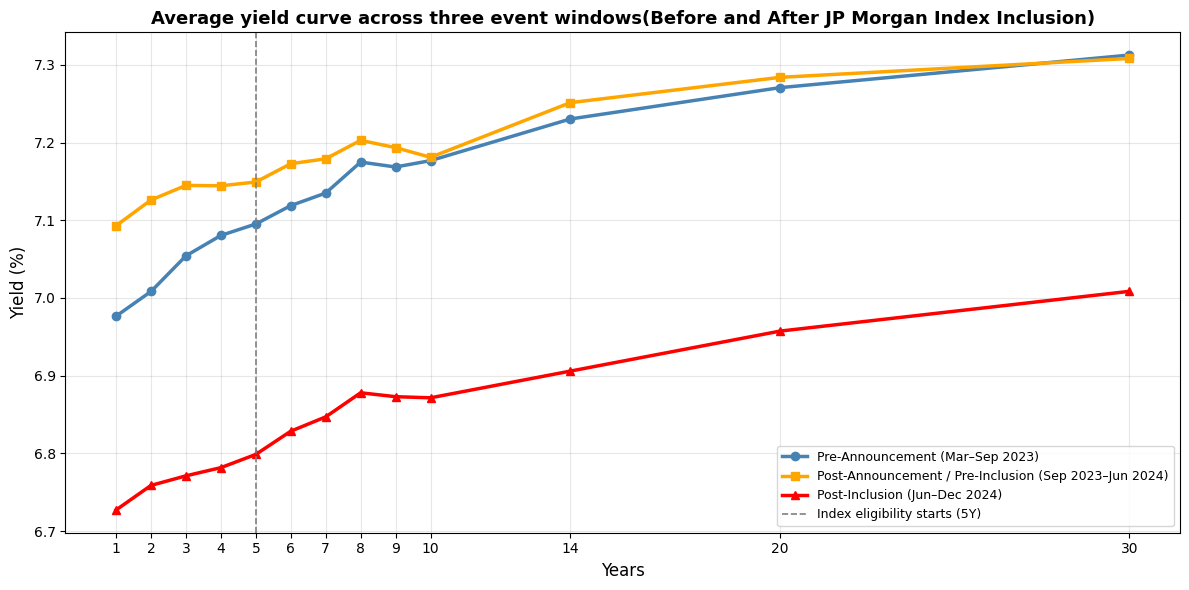

In [8]:
# ── BLOCK 3: EVENT STUDY PLOT ──
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(tenors, avg_pre_ann.values,color='steelblue', linewidth=2.5, marker='o',markersize=6, label='Pre-Announcement (Mar–Sep 2023)')
ax.plot(tenors, avg_pre_inc.values,color='orange', linewidth=2.5, marker='s',markersize=6, label='Post-Announcement / Pre-Inclusion (Sep 2023–Jun 2024)')
ax.plot(tenors, avg_post_inc.values,color='red', linewidth=2.5, marker='^',markersize=6, label='Post-Inclusion (Jun–Dec 2024)')
ax.axvline(5, color='gray', linestyle='--',linewidth=1.2, label='Index eligibility starts (5Y)')
ax.set_xlabel('Years', fontsize=12)
ax.set_ylabel('Yield (%)', fontsize=12)
ax.set_title('Average yield curve across three event windows(Before and After JP Morgan Index Inclusion)',fontsize=13, fontweight='bold')
ax.set_xticks(tenors)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\event_study_yield_curves.png',dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
suppression = pd.DataFrame({
    'Tenor'             : tenors,
    'Pre_Ann_yield'     : avg_pre_ann.values.round(4),
    'Post_Inc_yield'    : avg_post_inc.values.round(4),
    'Suppression_bps'   : ((avg_pre_ann.values - avg_post_inc.values) * 100).round(1)
})

print(suppression.to_string(index=False))
print(f'Average suppression across all tenors : {suppression["Suppression_bps"].mean():.1f} bps')
print(f'Max suppression: {suppression["Suppression_bps"].max():.1f} bps at {suppression.loc[suppression["Suppression_bps"].idxmax(), "Tenor"]}Y')
print(f'Min suppression: {suppression["Suppression_bps"].min():.1f} bps at {suppression.loc[suppression["Suppression_bps"].idxmin(), "Tenor"]}Y')
suppression.to_csv(r'C:\Users\Spandan Dutta\econometrics_project\outputs\tables\event_study_suppression.csv', index=False)

 Tenor  Pre_Ann_yield  Post_Inc_yield  Suppression_bps
     1         6.9766          6.7272             24.9
     2         7.0084          6.7588             25.0
     3         7.0542          6.7711             28.3
     4         7.0805          6.7817             29.9
     5         7.0952          6.7987             29.7
     6         7.1189          6.8286             29.0
     7         7.1350          6.8470             28.8
     8         7.1749          6.8780             29.7
     9         7.1686          6.8730             29.6
    10         7.1768          6.8715             30.5
    14         7.2304          6.9059             32.4
    20         7.2707          6.9574             31.3
    30         7.3126          7.0086             30.4
Average suppression across all tenors : 29.2 bps
Max suppression: 32.4 bps at 14Y
Min suppression: 24.9 bps at 1Y
